# Accessing and Analysing Sentinel-5P Products in CDSE

In this notebook, we will walk through the steps to access and analyse Sentinel-5P atmospheric composition products using the openEO API within the Copernicus Data Space Ecosystem (CDSE).

The notebook covers the basic steps for accessing and analysing Sentinel-5P Aerosol Index products, for the Benelux region for a day.

Additionally, the example also shows how to use the `qa_value` band to mask lower-quality observations.

*Please note that this notebook is designed as a beginner-friendly introduction to accessing Sentinel-5P data with openEO and is not intended to provide a complete atmospheric-science analysis.*

In [2]:
import openeo

import pandas as pd

# connect with the backend
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


The first step after importing the openEO Python client is to establish a connection to the CDSE backend and authenticate the account using the `authenticate_oidc()` method, as shown above.

While users can explore the available collections and process without authentication, certain operations, such as submitting batch jobs or accessing collections, require an authenticated connection.

Before we proceed, let us explore the list of available Sentinel-5P collections. This will help us identify the relevant products for our analysis. While in the cell below, we are filtering the collections by title to narrow down the results to Sentinel-5P products, it is recommended to inspect the full list to ensure no relevant collections are overlooked.

In [3]:
# use `list_collections()` to get an overview of the available collections in the backend
collections = connection.list_collections()
collection_overview = []
# Filter collections with "Sentinel5P" in their title
for collection in collections:
    if "title" in collection and "Sentinel-5P" in collection["title"]:
        collection_overview.append(
            {
                "Collection ID": collection.get('id'),
                "Title": collection.get('title'),
                "Description": collection.get('description')
            }
        )

collection_overview_df = pd.DataFrame(collection_overview)
print(f"Found {len(collection_overview_df)} collections with 'Sentinel-5P' in the title.")

# Let us have a clean view of the collection
with pd.option_context('display.max_colwidth', None):
    display(collection_overview_df[:3])

Found 9 collections with 'Sentinel-5P' in the title.


,Collection ID,Title,Description
0,SENTINEL5P_L2_CO,Sentinel-5P TROPOMI Carbon Monoxide L2,"This Collection provides Sentinel-5P Level-2 CO products, which contains high-resolution imagery of carbon monoxide concentrations.\n\nSee the [Product User Manual](https://sentiwiki.copernicus.eu/__attachments/a_8cada11082dbfd5ea78cb0d1f7dfc9cd4c58025905c8651a404fa90d6e98d03f/SRON-S5P-LEV2-MA-002%20-%20Sentinel-5P%20Level%202%20Product%20User%20Manual%20Carbon%20Monoxide%202025-2.9.1.pdf) for details."
1,SENTINEL5P_L2_NO2,Sentinel-5P TROPOMI Nitrogendioxide L2,"This Collection provides Sentinel-5P Level-2 NO2 products, which contains high-resolution imagery of nitrogen dioxide concentrations.\n\nSee the [Product User Manual](https://sentiwiki.copernicus.eu/__attachments/a_9a684b9fae014dbd44f68f924be68b04ef2a8740ab3a4a756a2b18393c06a80b/S5P-KNMI-L2-0021-MA%20-%20Sentinel-5P%20Level%202%20Product%20User%20Manual%20Nitrogendioxide%202025-4.5.0.pdf) for details."
2,SENTINEL5P_L2_CH4,Sentinel-5P TROPOMI Methane L2,"This Collection provides Sentinel-5P Level-2 CH4 products, which contains high-resolution imagery of methane concentrations.\n\nSee the [Product User Manual](https://sentiwiki.copernicus.eu/__attachments/a_046c3abe4195dd4adb791aef506b27270ed4a9080ae56ead0282f38c503a44e7/SRON-S5P-LEV2-MA-001%20-%20Sentinel-5P%20Level%202%20Product%20User%20Manual%20Methane%202025-2.9.1.pdf) for details."



The collection listing provides an overview of the Sentinel-5P products offered by the backend that can be accessed using openEO. 

As mentioned earlier, in this notebook, we are showcasing a simple workflow for accessing and analysing Sentinel-5P Aerosol Index products over the Benelux region, so let us define the area of interest for a single day.

In [4]:
# BENELUX bounding box
bbox = { "west": 3, "south": 50, "east": 8, "north": 54 } 
time_period = ["2023-06-09", "2023-06-09"]

# load aerosol index band
cube_ai = connection.load_collection(
    "SENTINEL5P_L2_AER_AI",
    spatial_extent=bbox,
    temporal_extent=time_period,
    bands=["aerosol_index_354_388"]
)
cube_ai

We used simple [`load_collection`](https://openeo.org/documentation/1.0/processes.html#load_collection) to access the aerosol index data for the specified spatial extent and for a single day.


Similarly, let us also load the QA value band for the same region and time period to further mask the aerosol index data.

In [5]:
# load quality assurance band
cube_qa = connection.load_collection(
    "SENTINEL5P_L2_AER_AI",
    spatial_extent=bbox,
    temporal_extent=time_period,
    bands=["qa_value"]
)


In the above cells, we have loaded the Sentinel-5P Aerosol Index data and the corresponding quality assurance band for the Benelux region for a single day in June 2023. We now have 2 datacubes: one containing the aerosol index at 354–388 nm and another containing the `qa_value` band.

In [6]:
# quality filtering based on the qa_value band
mask_qa = cube_qa < 0.5
masked_cube = cube_ai.mask(mask_qa)
masked_cube

Above, we created a quality mask datacube by selecting pixels with a `qa_value` below 0.5 to filter out low-quality observations.

The processed data cube is then submitted as an openEO batch job using the `execute_batch` process and the resulting output is saved as NetCDF file. 

In [7]:
masked_cube.execute_batch(title="Masked Aerosol Index Benelux", outputfile="masked_aerosol_index_benelux.nc")

0:00:00 Job 'j-26091712321140c3844a350c1d781314': send 'start'
0:00:04 Job 'j-26091712321140c3844a350c1d781314': created (progress 0%)
0:00:09 Job 'j-26091712321140c3844a350c1d781314': queued (progress 0%)
0:00:16 Job 'j-26091712321140c3844a350c1d781314': queued (progress 0%)
0:00:24 Job 'j-26091712321140c3844a350c1d781314': queued (progress 0%)
0:00:33 Job 'j-26091712321140c3844a350c1d781314': queued (progress 0%)
0:00:46 Job 'j-26091712321140c3844a350c1d781314': queued (progress 0%)
0:01:01 Job 'j-26091712321140c3844a350c1d781314': queued (progress 0%)
0:01:21 Job 'j-26091712321140c3844a350c1d781314': running (progress N/A)
0:01:45 Job 'j-26091712321140c3844a350c1d781314': running (progress N/A)
0:02:15 Job 'j-26091712321140c3844a350c1d781314': finished (progress 100%)


<BatchJob job_id='j-26091712321140c3844a350c1d781314'>

C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_31916\3126718171.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  grid.fig.tight_layout()


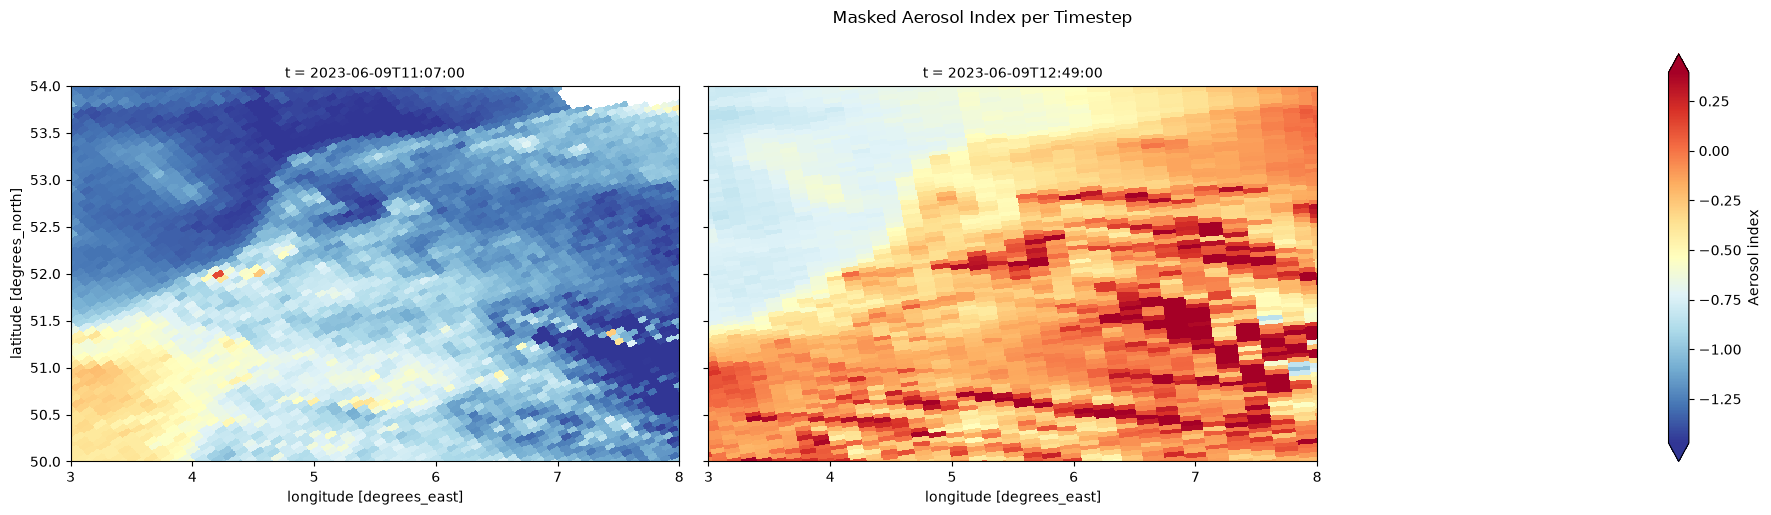

In [15]:
### Plot one map per timestep for masked_aerosol_index_benelux.nc
import matplotlib.pyplot as plt
import xarray as xr

with xr.open_dataset("masked_aerosol_index_benelux.nc") as ds:
    data = ds["aerosol_index_354_388"].load()

vmin, vmax = data.quantile([0.02, 0.98], skipna=True).values
time = next((dim for dim in ("time", "t") if dim in data.dims), None)
plot_kwargs = {"cmap": "RdYlBu_r", "vmin": float(vmin), "vmax": float(vmax),"cbar_kwargs": {"label": "Aerosol index"},}

if time is None:
    fig, ax = plt.subplots(figsize=(11, 8))
    data.plot(ax=ax, **plot_kwargs)
    ax.set_title("Masked Aerosol Index")
    plt.tight_layout()
else:
    grid = data.plot(col=time, col_wrap=3, size=5, aspect=1.25,**plot_kwargs)
    grid.fig.suptitle("Masked Aerosol Index per Timestep", y=1.02)
    grid.fig.tight_layout()

plt.show()

Though we take a single day, for Sentinel-5P it is also possible that there are more acquisitions per day, which can be aggregated to create daily composites. Therefore in the case of multiple acquisitions per day, it is recommended to perform temporal aggregation to obtain a representative daily value.

In [9]:
day_median_cube = masked_cube.median_time()
day_median_cube.execute_batch(title="Download Median of Daily Composites", outputfile="day_median_cube.nc")

0:00:00 Job 'j-26091712350544eebfa1d8afb240a6fd': send 'start'
0:00:04 Job 'j-26091712350544eebfa1d8afb240a6fd': queued (progress 0%)
0:00:09 Job 'j-26091712350544eebfa1d8afb240a6fd': queued (progress 0%)
0:00:16 Job 'j-26091712350544eebfa1d8afb240a6fd': queued (progress 0%)
0:00:23 Job 'j-26091712350544eebfa1d8afb240a6fd': queued (progress 0%)
0:00:33 Job 'j-26091712350544eebfa1d8afb240a6fd': queued (progress 0%)
0:00:46 Job 'j-26091712350544eebfa1d8afb240a6fd': queued (progress 0%)
0:01:01 Job 'j-26091712350544eebfa1d8afb240a6fd': queued (progress 0%)
0:01:21 Job 'j-26091712350544eebfa1d8afb240a6fd': running (progress N/A)
0:01:45 Job 'j-26091712350544eebfa1d8afb240a6fd': running (progress N/A)
0:02:15 Job 'j-26091712350544eebfa1d8afb240a6fd': running (progress N/A)
0:02:53 Job 'j-26091712350544eebfa1d8afb240a6fd': finished (progress 100%)


<BatchJob job_id='j-26091712350544eebfa1d8afb240a6fd'>

Let us visualise the temporal median of the daily aerosol-index composites.

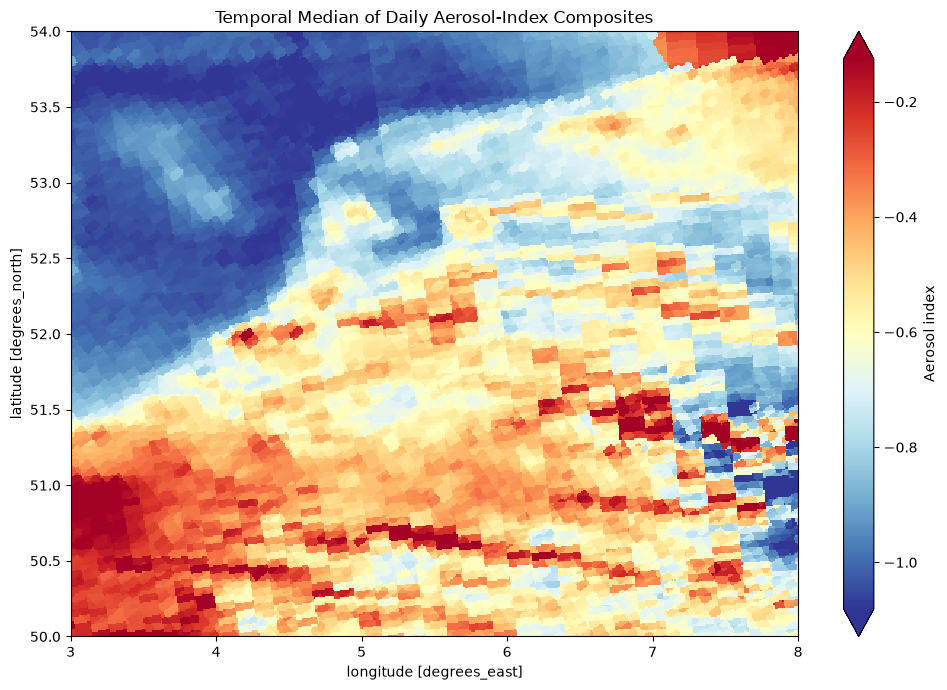

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr

with xr.open_dataset("day_median_cube.nc") as ds:
    data = ds["aerosol_index_354_388"].load()

fig, ax = plt.subplots(figsize=(10, 7))
data.plot(ax=ax, cmap="RdYlBu_r", robust=True, cbar_kwargs={"label": "Aerosol index"},)
ax.set_title("Temporal Median of Daily Aerosol-Index Composites")
plt.tight_layout()
plt.show()